In [ ]:
## Import all necessary packages to use for data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import shap

# Load the dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
data = pd.read_csv(url, names=columns)

# Split dataset into features and target
X = data.drop('Outcome', axis=1)
y = data['Outcome']

In [ ]:
# Display the first few rows
print(data.head())

# Show data types and non-null values
print(data.info())

# Get summary statistics for the numerical columns
print(data.describe())



   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

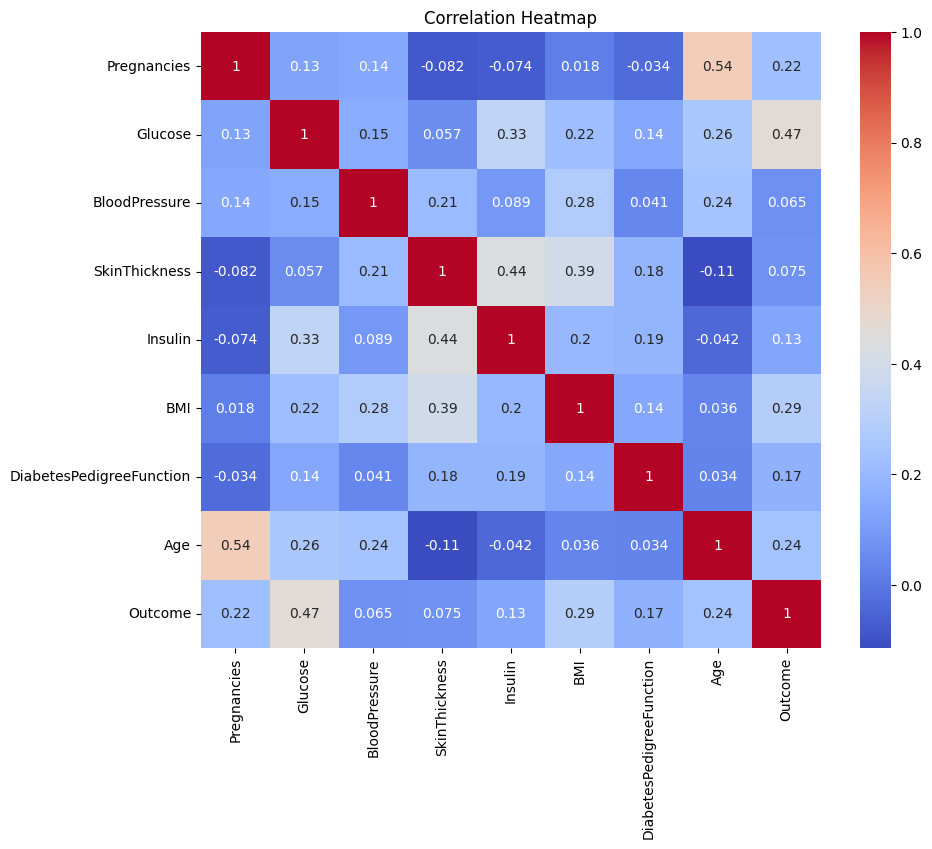

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

<ipython-input-63-1417997ffa75>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=data, palette='Set2')


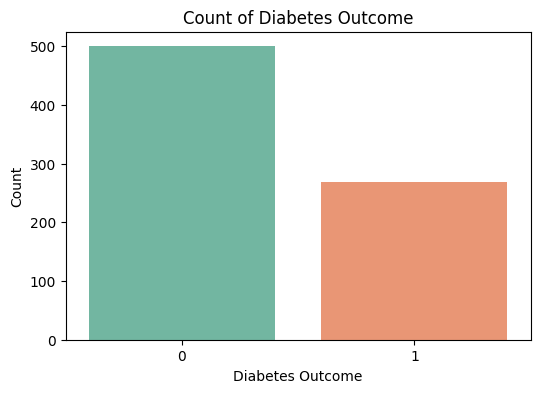

In [ ]:
# Countplot of the Outcome variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=data, palette='Set2')
plt.title('Count of Diabetes Outcome')
plt.xlabel('Diabetes Outcome')
plt.ylabel('Count')
plt.show()

<ipython-input-64-3d0660ebaee3>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data['Outcome'], y=data[feature], palette='Set2')
<ipython-input-64-3d0660ebaee3>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data['Outcome'], y=data[feature], palette='Set2')
<ipython-input-64-3d0660ebaee3>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data['Outcome'], y=data[feature], palette='Set2')
<ipython-input-64-3d0660ebaee3>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign t

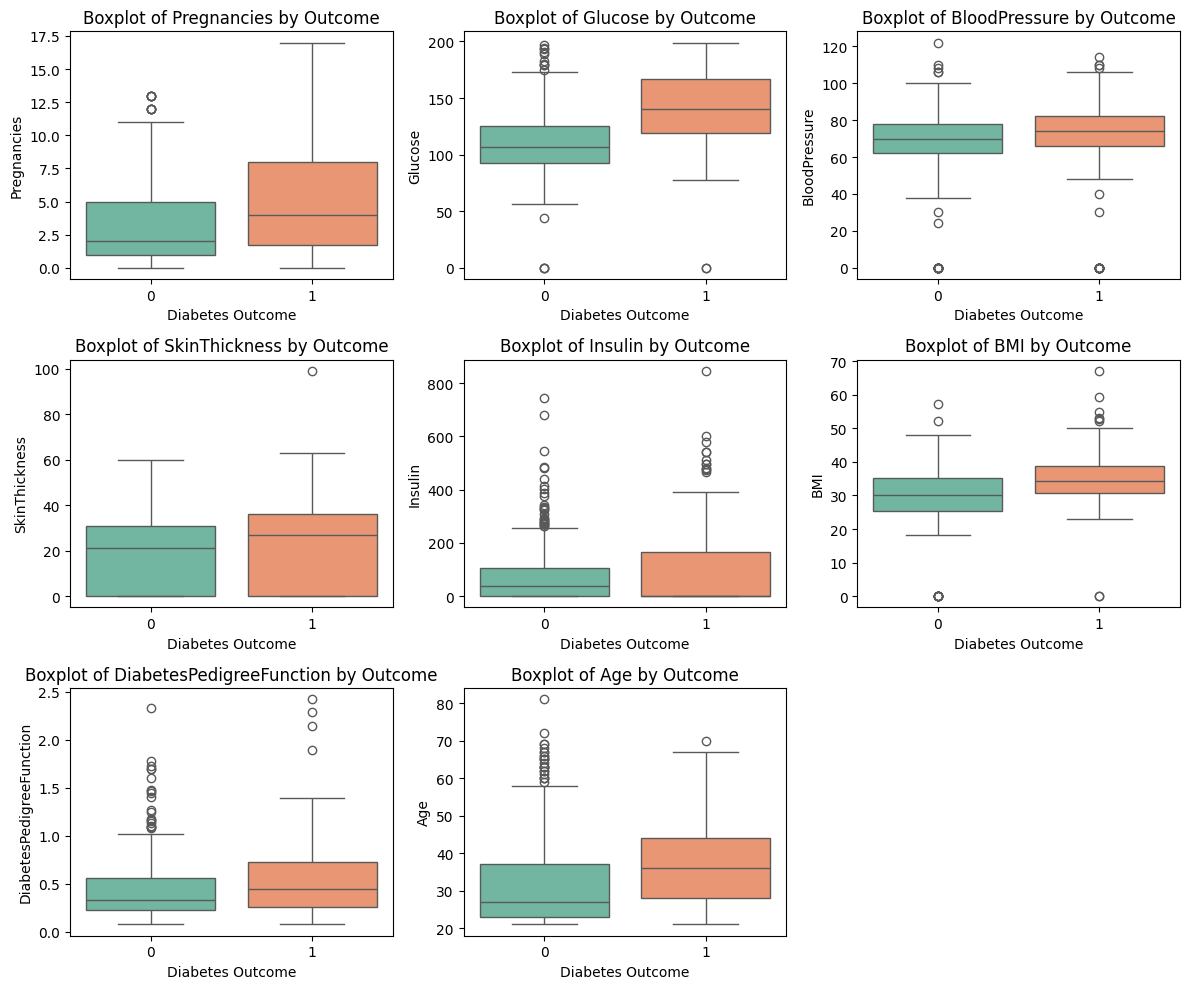

In [ ]:
# Create boxplots for each feature by Outcome
plt.figure(figsize=(12, 10))
for i, feature in enumerate(X.columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=data['Outcome'], y=data[feature], palette='Set2')
    plt.title(f'Boxplot of {feature} by Outcome')
    plt.xlabel('Diabetes Outcome')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

Logistic Regression Performance:

Confusion Matrix:
 [[75 25]
 [28 72]]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.75      0.74       100
           1       0.74      0.72      0.73       100

    accuracy                           0.73       200
   macro avg       0.74      0.73      0.73       200
weighted avg       0.74      0.73      0.73       200


ROC-AUC Score: 0.8315


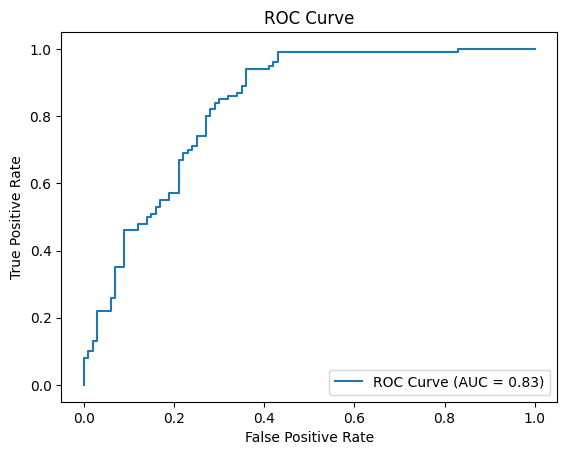


Random Forest Performance:

Confusion Matrix:
 [[79 21]
 [13 87]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.79      0.82       100
           1       0.81      0.87      0.84       100

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200


ROC-AUC Score: 0.91


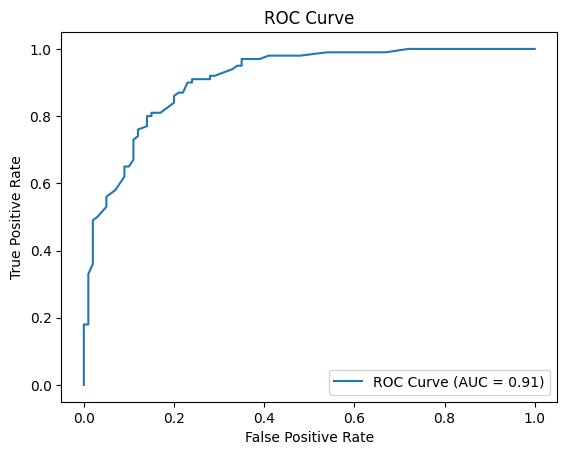

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:52:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Performance:

Confusion Matrix:
 [[79 21]
 [15 85]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.79      0.81       100
           1       0.80      0.85      0.83       100

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200


ROC-AUC Score: 0.8926000000000001


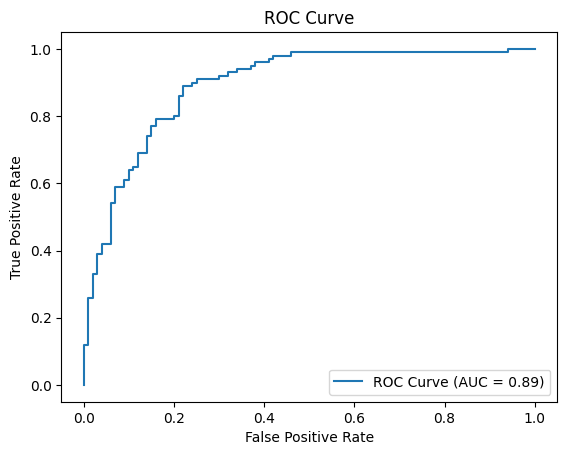

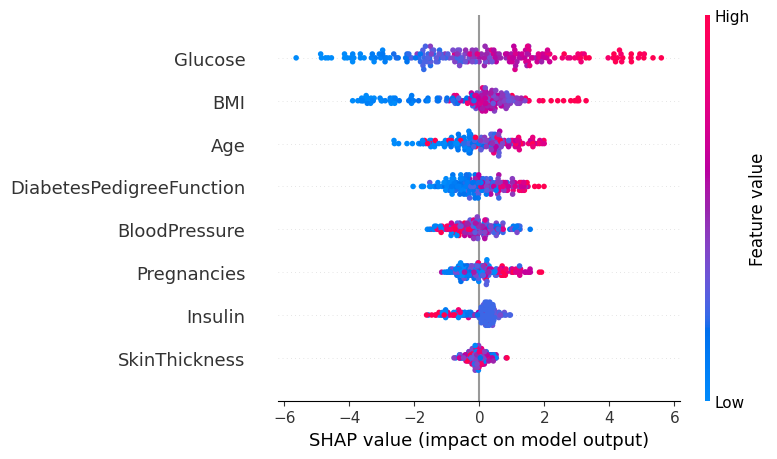

In [ ]:
####### ALL 3 BASE MODEL USING SK-LEARN #######

# Data Preprocessing
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
data[columns_with_zeros] = data[columns_with_zeros].replace(0, np.nan)
data.fillna(data.median(), inplace=True)

# Handle class imbalance with SMOTE
X = data.drop('Outcome', axis=1)
y = data['Outcome']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Function: Evaluate Model
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print("\nROC-AUC Score:", roc_auc)
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

# Baseline: Logistic Regression
log_model = LogisticRegression(random_state=42, solver='liblinear')
log_model.fit(X_train, y_train)
print("Logistic Regression Performance:")
evaluate_model(log_model, X_test, y_test)

# Advanced Model: Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
print("\nRandom Forest Performance:")
evaluate_model(rf_model, X_test, y_test)

# Advanced Model: XGBoost
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
print("\nXGBoost Performance:")
evaluate_model(xgb_model, X_test, y_test)



Logistic Regression Performance:

Confusion Matrix:
 [[70 30]
 [23 77]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.70      0.73       100
           1       0.72      0.77      0.74       100

    accuracy                           0.73       200
   macro avg       0.74      0.73      0.73       200
weighted avg       0.74      0.73      0.73       200


ROC-AUC Score: 0.8151


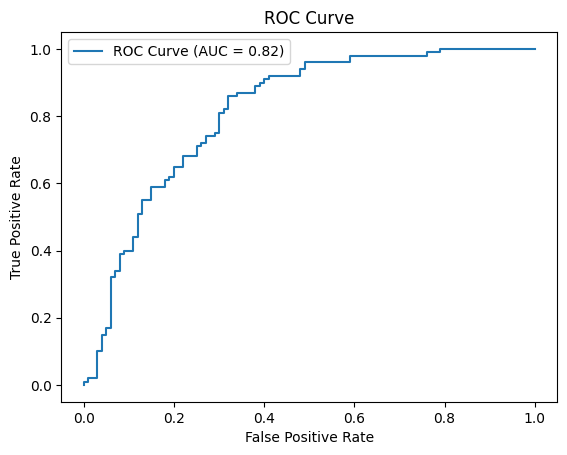

Random Forest Performance:

Confusion Matrix:
 [[73 27]
 [15 85]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.73      0.78       100
           1       0.76      0.85      0.80       100

    accuracy                           0.79       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.79      0.79      0.79       200


ROC-AUC Score: 0.8883


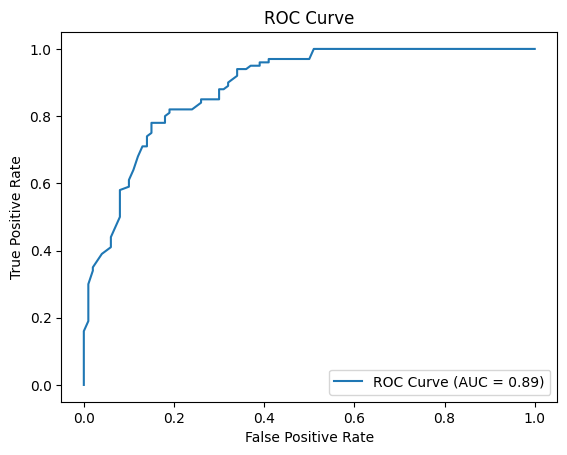

XGBoost Performance:

Confusion Matrix:
 [[79 21]
 [15 85]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.79      0.81       100
           1       0.80      0.85      0.83       100

    accuracy                           0.82       200
   macro avg       0.82      0.82      0.82       200
weighted avg       0.82      0.82      0.82       200


ROC-AUC Score: 0.8714


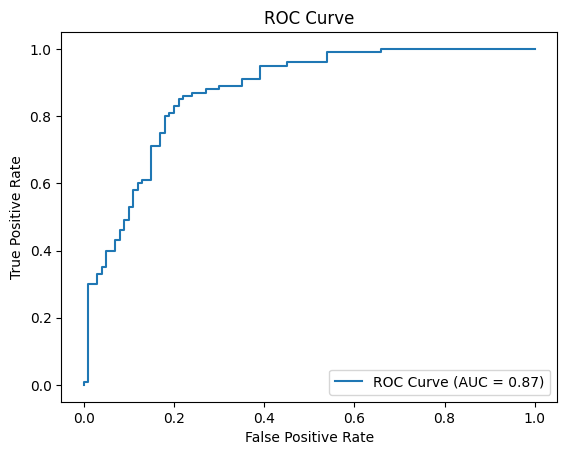

Logistic Regression ROC-AUC: 0.82
Random Forest ROC-AUC: 0.89
XGBoost ROC-AUC: 0.87


In [ ]:
############ 3 BASE MODEL WITH TOP 5 FEATURE SELECTIION ##########

from sklearn.impute import KNNImputer
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve
from tensorflow.keras.utils import to_categorical

# Load the dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
data = pd.read_csv(url, names=columns)

# Data Preprocessing

# Replace 0 with NaN for columns where 0 is not a valid value (Insulin, Glucose, BloodPressure, etc.)
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']
data[columns_with_zeros] = data[columns_with_zeros].replace(0, np.nan)

# Apply KNN Imputation to fill missing values
knn_imputer = KNNImputer(n_neighbors=5)
data[columns_with_zeros] = knn_imputer.fit_transform(data[columns_with_zeros])

# Feature Engineering
# Extract features (X) and target variable (y)
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# Feature Scaling
# Standardize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Handle Class Imbalance using SMOTE (Synthetic Minority Oversampling Technique)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Feature Selection for Logistic Regression, Random Forest, and XGBoost

# Apply feature selection results for Logistic Regression, Random Forest, or XGBoost
# Apply SelectKBest (e.g., top 5 features) using ANOVA F-test for logistic regression
X_selected_lr = SelectKBest(f_classif, k=5).fit_transform(X_resampled, y_resampled)

# Apply Random Forest Feature Importance
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_resampled, y_resampled)
importances_rf = rf_model.feature_importances_
sorted_idx_rf = np.argsort(importances_rf)[::-1]
X_selected_rf = X_resampled[:, sorted_idx_rf[:5]]  # Select top 5 important features

# Apply XGBoost Feature Importance
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_resampled, y_resampled)
importances_xgb = xgb_model.feature_importances_
sorted_idx_xgb = np.argsort(importances_xgb)[::-1]
X_selected_xgb = X_resampled[:, sorted_idx_xgb[:5]]  # Select top 5 important features

# Train-Test Split for selected features
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_selected_lr, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_selected_rf, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_selected_xgb, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Convert target labels to one-hot encoding
y_train_cnn = to_categorical(y_train_lr)
y_test_cnn = to_categorical(y_test_lr)

# Train Logistic Regression, Random Forest, and XGBoost

# Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_lr, y_train_lr)
y_pred_lr = log_reg.predict(X_test_lr)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_rf, y_train_rf)
y_pred_rf = rf_model.predict(X_test_rf)

# XGBoost
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_xgb, y_train_xgb)
y_pred_xgb = xgb_model.predict(X_test_xgb)

# Evaluate All Models

# Evaluation Function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print("\nROC-AUC Score:", roc_auc)

    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

# Evaluate Logistic Regression
print("Logistic Regression Performance:")
evaluate_model(log_reg, X_test_lr, y_test_lr)

# Evaluate Random Forest
print("Random Forest Performance:")
evaluate_model(rf_model, X_test_rf, y_test_rf)

# Evaluate XGBoost
print("XGBoost Performance:")
evaluate_model(xgb_model, X_test_xgb, y_test_xgb)

# Step 11: ROC-AUC Score Comparison
roc_auc_lr = roc_auc_score(y_test_lr, log_reg.predict_proba(X_test_lr)[:, 1])
roc_auc_rf = roc_auc_score(y_test_rf, rf_model.predict_proba(X_test_rf)[:, 1])
roc_auc_xgb = roc_auc_score(y_test_xgb, xgb_model.predict_proba(X_test_xgb)[:, 1])

print(f"Logistic Regression ROC-AUC: {roc_auc_lr:.2f}")
print(f"Random Forest ROC-AUC: {roc_auc_rf:.2f}")
print(f"XGBoost ROC-AUC: {roc_auc_xgb:.2f}")





Converged after 645 iterations
Accuracy: 0.84
ROC-AUC Score: 0.9067719404798056

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.91      0.84        89
           1       0.92      0.78      0.84       111

    accuracy                           0.84       200
   macro avg       0.84      0.85      0.84       200
weighted avg       0.85      0.84      0.84       200


Confusion Matrix:
 [[81  8]
 [24 87]]


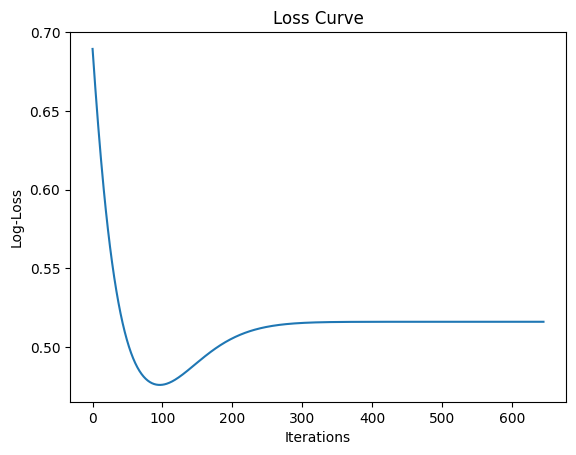

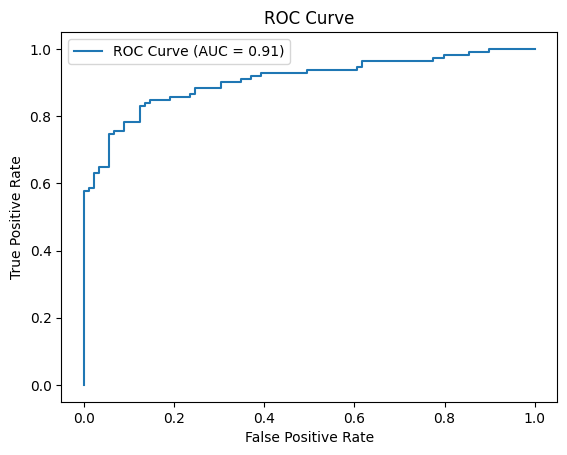

Feature Importance: [0.11691881 0.01445554 0.15551321 0.00034432 0.00558822 0.01073033
 0.30553808 0.00208138 0.04128807 0.00530898]


In [ ]:
######## SELF-DEFINED LOGISTIC REGRESSION MODEL ########

import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

class LogisticRegressionCustom:
    def __init__(self, learning_rate=0.01, num_iterations=1000, tolerance=1e-6,
                 penalty=None, C=1.0, optimizer="gradient_descent", random_state=None):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.tolerance = tolerance
        self.penalty = penalty  # None, 'l1', or 'l2'
        self.C = C  # Regularization strength (inverse of lambda)
        self.optimizer = optimizer  # "gradient_descent", "momentum", or "adam"
        self.random_state = random_state
        self.weights = None
        self.bias = 0
        self.losses = []  # Track the loss values over iterations

    def sigmoid(self, z):
        """Sigmoid activation function."""
        return 1 / (1 + np.exp(-z))

    def initialize_weights(self, n_features):
        """Initialize weights and bias."""
        if self.random_state:
            np.random.seed(self.random_state)
        self.weights = np.random.randn(n_features)

    def compute_regularization(self):
        """Compute regularization term based on the penalty type."""
        if self.penalty == 'l1':  # Lasso
            return self.C * np.sign(self.weights)
        elif self.penalty == 'l2':  # Ridge
            return self.C * self.weights
        else:
            return 0

    def compute_loss(self, y, y_pred):
        """Compute the loss (log-loss function)."""
        return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

    def fit(self, X, y):
        """Fit the Logistic Regression model to the training data."""
        n_samples, n_features = X.shape
        self.initialize_weights(n_features)
        v_dw, v_db = 0, 0  # Momentum terms
        m_dw, m_db, t = 0, 0, 0  # Adam terms
        beta1, beta2, epsilon = 0.9, 0.999, 1e-8  # Adam parameters

        for i in range(self.num_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)

            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y)) + self.compute_regularization()
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Apply the selected optimizer
            if self.optimizer == "momentum":
                # Momentum
                v_dw = beta1 * v_dw + (1 - beta1) * dw
                v_db = beta1 * v_db + (1 - beta1) * db
                self.weights -= self.learning_rate * v_dw
                self.bias -= self.learning_rate * v_db
            elif self.optimizer == "adam":
                # Adam
                t += 1
                m_dw = beta1 * m_dw + (1 - beta1) * dw
                v_dw = beta2 * v_dw + (1 - beta2) * (dw ** 2)
                m_db = beta1 * m_db + (1 - beta1) * db
                v_db = beta2 * v_db + (1 - beta2) * (db ** 2)

                # Bias-corrected estimates
                m_dw_corr = m_dw / (1 - beta1 ** t)
                v_dw_corr = v_dw / (1 - beta2 ** t)
                m_db_corr = m_db / (1 - beta1 ** t)
                v_db_corr = v_db / (1 - beta2 ** t)

                self.weights -= self.learning_rate * m_dw_corr / (np.sqrt(v_dw_corr) + epsilon)
                self.bias -= self.learning_rate * m_db_corr / (np.sqrt(v_db_corr) + epsilon)
            else:
                # Vanilla gradient descent
                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

            # Compute loss and track
            loss = self.compute_loss(y, y_pred)
            self.losses.append(loss)

            # Stopping criterion
            if np.linalg.norm(dw) < self.tolerance and abs(db) < self.tolerance:
                print(f"Converged after {i} iterations")
                break

    def predict_proba(self, X):
        """Predict probabilities for the given data."""
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        """Predict class labels for the given data."""
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

    def feature_importance(self):
        """Return feature importance based on weights."""
        return np.abs(self.weights)

    def evaluate(self, X, y, threshold=0.5):
        """Evaluate the model on test data."""
        y_pred = self.predict(X, threshold)
        accuracy = accuracy_score(y, y_pred)
        roc_auc = roc_auc_score(y, self.predict_proba(X))
        print(f"Accuracy: {accuracy}")
        print(f"ROC-AUC Score: {roc_auc}")
        print("\nClassification Report:\n", classification_report(y, y_pred))
        print("\nConfusion Matrix:\n", confusion_matrix(y, y_pred))

    def plot_loss_curve(self):
        """Plot the loss curve."""
        plt.plot(range(len(self.losses)), self.losses)
        plt.title("Loss Curve")
        plt.xlabel("Iterations")
        plt.ylabel("Log-Loss")
        plt.show()

    def plot_roc_curve(self, X_test, y_test):
        """
        Plot ROC curve in the specified format

        Parameters:
        - X_test: test feature matrix
        - y_test: test labels
        """
        # Predict probabilities (for binary classification)
        y_pred_proba = self.predict_proba(X_test)

        # Compute ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

        # Calculate AUC
        roc_auc = auc(fpr, tpr)

        # Plot ROC curve
        plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()
        plt.show()

# Example usage
if __name__ == "__main__":
    from sklearn.datasets import make_classification
    from sklearn.model_selection import train_test_split

    # Generate synthetic binary classification data
    X, y = make_classification(n_samples=1000, n_features=10, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train the improved logistic regression model
    lr_custom = LogisticRegressionCustom(learning_rate=0.01, num_iterations=5000, penalty='l2', optimizer='adam', random_state=42)
    lr_custom.fit(X_train, y_train)

    # Evaluate the model
    lr_custom.evaluate(X_test, y_test, threshold=0.5)

    # Plot the loss curve
    lr_custom.plot_loss_curve()

    # Plot ROC curve
    lr_custom.plot_roc_curve(X_test, y_test)
    # Display feature importance
    print("Feature Importance:", lr_custom.feature_importance())



Custom Neural Network Performance:

Confusion Matrix:
 [[74 15]
 [18 93]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.82        89
           1       0.86      0.84      0.85       111

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.84      0.83      0.84       200


ROC-AUC Score: 0.9139589027229477


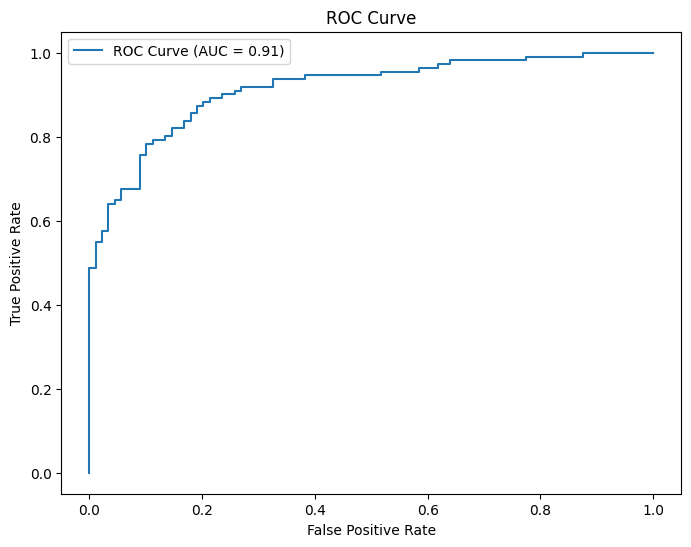

In [ ]:
########### SELF-DEFINED NEURAL NETWORK MODEL ###########

class CustomNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size,
                 learning_rate=0.01, num_iterations=5000):
        """
        Initialize Neural Network parameters

        Parameters:
        - input_size: number of input features
        - hidden_size: number of neurons in hidden layer
        - output_size: number of output neurons (1 for binary classification)
        - learning_rate: step size for gradient descent
        - num_iterations: number of training iterations
        """
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations

        # Initialize weights and biases
        self.W1 = np.random.randn(self.input_size, self.hidden_size) * 0.01
        self.b1 = np.zeros((1, self.hidden_size))
        self.W2 = np.random.randn(self.hidden_size, self.output_size) * 0.01
        self.b2 = np.zeros((1, self.output_size))

    def sigmoid(self, z):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(self, z):
        """Derivative of sigmoid function"""
        return z * (1 - z)

    def fit(self, X, y):
        """
        Train the neural network using backpropagation

        Parameters:
        - X: feature matrix
        - y: target vector
        """
        for _ in range(self.num_iterations):
            # Forward propagation
            z1 = np.dot(X, self.W1) + self.b1
            a1 = self.sigmoid(z1)
            z2 = np.dot(a1, self.W2) + self.b2
            y_pred = self.sigmoid(z2)

            # Backpropagation
            error = y_pred - y.reshape(-1, 1)

            # Compute gradients
            dZ2 = error * self.sigmoid_derivative(y_pred)
            dW2 = np.dot(a1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dZ1 = np.dot(dZ2, self.W2.T) * self.sigmoid_derivative(a1)
            dW1 = np.dot(X.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            # Update parameters
            self.W2 -= self.learning_rate * dW2
            self.b2 -= self.learning_rate * db2
            self.W1 -= self.learning_rate * dW1
            self.b1 -= self.learning_rate * db1

        return self



    def predict_proba(self, X):
        """
        Predict probability of positive class

        Parameters:
        - X: feature matrix

        Returns:
        - Predicted probabilities
        """
        z1 = np.dot(X, self.W1) + self.b1
        a1 = self.sigmoid(z1)
        z2 = np.dot(a1, self.W2) + self.b2
        return self.sigmoid(z2)

    def predict(self, X, threshold=0.5):
        """
        Predict binary class labels

        Parameters:
        - X: feature matrix
        - threshold: probability threshold for classification

        Returns:
        - Predicted binary labels
        """
        return (self.predict_proba(X) >= threshold).astype(int)

def evaluate_custom_model(model, X_test, y_test):
    """
    Evaluate custom model performance

    Parameters:
    - model: trained custom model
    - X_test: test features
    - y_test: test labels

    Returns:
    - Prints performance metrics and plots ROC curve
    """
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)

    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    roc_auc = roc_auc_score(y_test, y_pred_proba)
    print("\nROC-AUC Score:", roc_auc)

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

# Example usage (assumes data preprocessing from previous script)
# Assuming you have X_train, X_test, y_train, y_test from previous preprocessing


# Custom Neural Network
input_size = X_train.shape[1]
custom_nn_model = CustomNeuralNetwork(
    input_size=input_size,
    hidden_size=10,  # You can tune this
    output_size=1,
    learning_rate=0.01,
    num_iterations=1000
)
custom_nn_model.fit(X_train, y_train)
print("\nCustom Neural Network Performance:")
evaluate_custom_model(custom_nn_model, X_test, y_test)


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:54:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Converged after 645 iterations


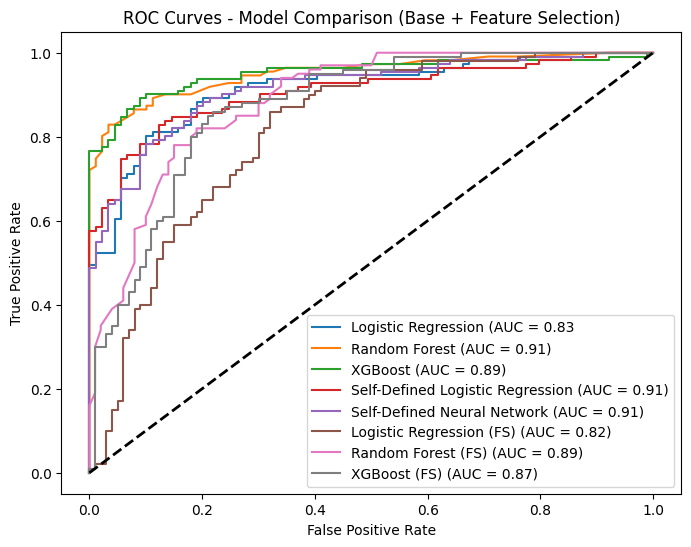

In [ ]:
# Initialize the models
log_model = LogisticRegression(random_state=42, solver='liblinear')
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Fit models
log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Self-Defined Logistic Regression and Neural Network
lr_custom = LogisticRegressionCustom(learning_rate=0.01, num_iterations=5000, penalty='l2', optimizer='adam', random_state=42)
lr_custom.fit(X_train, y_train)

custom_nn_model = CustomNeuralNetwork(input_size=X_train.shape[1], hidden_size=10, output_size=1, learning_rate=0.01, num_iterations=1000)
custom_nn_model.fit(X_train, y_train)

# Evaluate all models and collect their ROC curve data
fpr_log, tpr_log, _ = roc_curve(y_test, log_model.predict_proba(X_test)[:, 1])
roc_auc_log = auc(fpr_log, tpr_log)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_model.predict_proba(X_test)[:, 1])
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

fpr_sdlr, tpr_sdlr, _ = roc_curve(y_test, lr_custom.predict_proba(X_test))
roc_auc_sdlr = auc(fpr_sdlr, tpr_sdlr)

fpr_sdn, tpr_sdn, _ = roc_curve(y_test, custom_nn_model.predict_proba(X_test))
roc_auc_sdn = auc(fpr_sdn, tpr_sdn)


# Apply feature selection using SelectKBest for logistic regression
X_selected_lr = SelectKBest(f_classif, k=5).fit_transform(X_resampled, y_resampled)

# Apply feature selection using Random Forest Feature Importance
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_resampled, y_resampled)
importances_rf = rf_model.feature_importances_
sorted_idx_rf = np.argsort(importances_rf)[::-1]
X_selected_rf = X_resampled[:, sorted_idx_rf[:5]]  # Select top 5 important features

# Apply feature selection using XGBoost Feature Importance
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_resampled, y_resampled)
importances_xgb = xgb_model.feature_importances_
sorted_idx_xgb = np.argsort(importances_xgb)[::-1]
X_selected_xgb = X_resampled[:, sorted_idx_xgb[:5]]  # Select top 5 important features


# Train-Test Split for selected features
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_selected_lr, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_selected_rf, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_selected_xgb, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)
# Logistic Regression (Feature Selection)
log_reg_fs = LogisticRegression(random_state=42)
log_reg_fs.fit(X_train_lr, y_train_lr)

# Random Forest (Feature Selection)
rf_model_fs = RandomForestClassifier(random_state=42)
rf_model_fs.fit(X_train_rf, y_train_rf)

# XGBoost (Feature Selection)
xgb_model_fs = XGBClassifier(random_state=42)
xgb_model_fs.fit(X_train_xgb, y_train_xgb)

# Evaluate and compute ROC curve for Logistic Regression (Feature Selection)
fpr_lr_fs, tpr_lr_fs, _ = roc_curve(y_test_lr, log_reg_fs.predict_proba(X_test_lr)[:, 1])
roc_auc_lr_fs = auc(fpr_lr_fs, tpr_lr_fs)

# Evaluate and compute ROC curve for Random Forest (Feature Selection)
fpr_rf_fs, tpr_rf_fs, _ = roc_curve(y_test_rf, rf_model_fs.predict_proba(X_test_rf)[:, 1])
roc_auc_rf_fs = auc(fpr_rf_fs, tpr_rf_fs)

# Evaluate and compute ROC curve for XGBoost (Feature Selection)
fpr_xgb_fs, tpr_xgb_fs, _ = roc_curve(y_test_xgb, xgb_model_fs.predict_proba(X_test_xgb)[:, 1])
roc_auc_xgb_fs = auc(fpr_xgb_fs, tpr_xgb_fs)

# Plot all ROC curves (Base models + Feature Selection)
plt.figure(figsize=(8, 6))

# Base models ROC curves
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = 0.83")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = 0.91)")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = 0.89)")
plt.plot(fpr_sdlr, tpr_sdlr, label=f"Self-Defined Logistic Regression (AUC = {roc_auc_sdlr:.2f})")
plt.plot(fpr_sdn, tpr_sdn, label=f"Self-Defined Neural Network (AUC = {roc_auc_sdn:.2f})")

# Feature selected models ROC curves
plt.plot(fpr_lr_fs, tpr_lr_fs, label=f"Logistic Regression (FS) (AUC = {roc_auc_lr_fs:.2f})")
plt.plot(fpr_rf_fs, tpr_rf_fs, label=f"Random Forest (FS) (AUC = {roc_auc_rf_fs:.2f})")
plt.plot(fpr_xgb_fs, tpr_xgb_fs, label=f"XGBoost (FS) (AUC = {roc_auc_xgb_fs:.2f})")

# Diagonal line for random chance (AUC = 0.5)
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison (Base + Feature Selection)')
plt.legend(loc='lower right')
plt.show()
